# NB15 — Finale Verifikation der ausgelieferten Konfiguration

Bildet die in `ml_httpstreaming/classifier_app.py` **ausgelieferte** Konfiguration exakt nach
und liefert alle Zahlen fuer den Bericht ab Kapitel 6.4.

**Konfiguration (1:1 aus der App):**

| | |
|---|---|
| Fenster | 10 s, nicht ueberlappend, `MIN_WINDOW = 8 s` |
| Trim | `TRIM_SECS` Sekunden am Anfang/Ende je Aufnahme |
| Stufe 1 | RandomForest(200, class_weight='balanced', random_state=42) auf den 14 `FEATURES_S1`, **ME-bereinigte** Fenster, Regel `CONF_S1_MIN = 0.75` |
| Stufe 2 | Pipeline(StandardScaler, SVC(rbf, C=10, class_weight='balanced')), **Movement Exclusion AUS** |
| Merkmalsauswahl Stufe 2 | group-aware permutation importance >= 0, **in jeder LOSO-Falte neu auf den Trainingsdaten** |

Die faltweise Selektion ist der entscheidende Unterschied zur App und zu NB13/NB14: dort wird
`feat_s2` einmal auf allen Daten bestimmt, was die LOSO-Zahl optimistisch verzerrt (die
Testfalte hat die Auswahl mitbestimmt). Hier ist sie unverzerrt.

In [1]:
import warnings, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, find_peaks
from scipy.stats import kurtosis, skew
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneGroupOut, GroupShuffleSplit, train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             classification_report, recall_score)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ── Konstanten 1:1 aus ml_httpstreaming/classifier_app.py ─────────────────────
BASE_DIR      = Path.cwd().parent
DATA_DIR      = BASE_DIR / 'data' / 'raw'
IMG_DIR       = BASE_DIR / 'reports' / 'images'

FS            = 50.0
TRIM_SECS     = 2       # app Z.63. ACHTUNG: Berichtsentwurf nennt 5 s -> hier bewusst
                        # der App-Wert. Eine Zeile aendern, falls 5 gewuenscht ist.
WINDOW_SECS   = 10.0
MIN_WINDOW    = 8.0
K_MOV         = 5
CONF_S1_MIN   = 0.75
MOVEMENT_EXCL = False   # Stufe 2: Deploy-Default

CLASSES_RAW   = ['Apfel', 'Kaugummi', 'Skyr', 'Still', 'Essen']
FOODS         = ['Apfel', 'Kaugummi', 'Skyr']
TO_COARSE     = {c: ('Still' if c == 'Still' else 'Essen') for c in CLASSES_RAW}

FEATURES_S1   = ['stillness_ratio', 'movement_events', 'magnitude_mean', 'magnitude_std',
                 'magnitude_max', 'jerk_mean', 'jerk_std', 'crest_factor', 'chews_per_sec',
                 'ac_peak_height', 'rhythmicity', 'chew_band_power', 'spectral_entropy',
                 'dominant_chew_freq']

RS = 42
print(f'Setup OK | Fenster={WINDOW_SECS:.0f}s | TRIM={TRIM_SECS}s | '
      f'CONF_S1_MIN={CONF_S1_MIN} | Stufe-1-Features={len(FEATURES_S1)}')

Setup OK | Fenster=10s | TRIM=2s | CONF_S1_MIN=0.75 | Stufe-1-Features=14


## 1. Feature-Extraktion — woertlich aus der App uebernommen

In [2]:
def _add_derived(df):
    df = df.copy()
    df['lin_x'] = df['accelerationX']
    df['lin_y'] = df['accelerationY']
    df['lin_z'] = df['accelerationZ']
    df['magnitude'] = np.sqrt(df['lin_x']**2 + df['lin_y']**2 + df['lin_z']**2)
    return df


def _movement_exclusion(df, k=K_MOV):
    thr = max(0.02, k * df['magnitude'].median())
    roll_max = df['magnitude'].rolling(50, center=True, min_periods=1).max()
    return df[roll_max <= thr].reset_index(drop=True)


def extract_features(df):
    f = {}
    for col in ['lin_x', 'lin_y', 'lin_z', 'magnitude']:
        f[f'{col}_mean'] = df[col].mean()
        f[f'{col}_std']  = df[col].std()
        f[f'{col}_max']  = df[col].abs().max()
    f['stillness_ratio'] = (df['magnitude'] < 0.02).mean()
    f['movement_events'] = int((df['magnitude'] > df['magnitude'].quantile(0.75)).sum())
    for col in ['rotationRateX', 'rotationRateY', 'rotationRateZ']:
        f[f'{col}_mean'] = df[col].mean()
        f[f'{col}_std']  = df[col].std()
        f[f'{col}_max']  = df[col].abs().max()
    for col in ['pitch', 'roll', 'yaw']:
        f[f'{col}_mean']  = df[col].mean()
        f[f'{col}_std']   = df[col].std()
        f[f'{col}_range'] = df[col].max() - df[col].min()
    nperseg = min(256, len(df) // 2)
    freqs, psd = welch(df['magnitude'].values, fs=FS, nperseg=nperseg)
    chew = (freqs >= 0.5) & (freqs <= 4.0)
    cf, cp = freqs[chew], psd[chew]
    f['total_power']        = float(psd.sum())
    f['chew_band_power']    = float(cp.sum())
    f['rhythmicity']        = f['chew_band_power'] / f['total_power'] if f['total_power'] > 0 else 0.0
    f['dominant_chew_freq'] = float(cf[np.argmax(cp)]) if len(cp) > 0 else 0.0

    mag = df['magnitude'].values
    t   = df['seconds_elapsed'].values if 'seconds_elapsed' in df else np.arange(len(df)) / FS
    dur = (t[-1] - t[0]) if len(t) > 1 else 0.0
    rms = np.sqrt(np.mean(mag**2)) if len(mag) else 0.0
    f['mag_kurtosis'] = float(kurtosis(mag)) if len(mag) > 3 else 0.0
    f['mag_skew']     = float(skew(mag))     if len(mag) > 2 else 0.0
    f['crest_factor'] = float(np.max(np.abs(mag)) / rms) if rms > 1e-9 else 0.0
    if len(mag) > 2:
        jerk = np.diff(mag) * FS
        f['jerk_mean'] = float(np.mean(np.abs(jerk)))
        f['jerk_std']  = float(np.std(jerk))
    else:
        f['jerk_mean'] = f['jerk_std'] = 0.0
    for k in ['spectral_entropy', 'spectral_centroid', 'spectral_bandwidth',
              'band_power_slow', 'band_power_mid', 'band_power_fast', 'high_freq_power']:
        f[k] = 0.0
    if nperseg >= 2 and psd.sum() > 0:
        tot = psd.sum(); p = psd / tot; pp = p[p > 0]
        f['spectral_entropy']   = float(-np.sum(pp * np.log2(pp)) / np.log2(len(p)))
        f['spectral_centroid']  = float(np.sum(freqs * p))
        f['spectral_bandwidth'] = float(np.sqrt(np.sum((freqs - f['spectral_centroid'])**2 * p)))
        band = lambda lo, hi: float(psd[(freqs >= lo) & (freqs < hi)].sum() / tot)
        f['band_power_slow'] = band(0.5, 1.5)
        f['band_power_mid']  = band(1.5, 2.5)
        f['band_power_fast'] = band(2.5, 4.0)
        f['high_freq_power'] = band(4.0, 15.0)
    f['ac_peak_height'] = 0.0
    f['chew_freq_ac']   = 0.0
    sig = mag - mag.mean() if len(mag) else mag
    if len(sig) > int(FS):
        ac = np.correlate(sig, sig, mode='full')[len(sig) - 1:]
        ac = ac / (ac[0] + 1e-12)
        lo, hi = int(FS / 4.0), min(int(FS / 0.5), len(ac) - 1)
        if hi > lo:
            peak = np.argmax(ac[lo:hi]) + lo
            f['ac_peak_height'] = float(ac[peak])
            f['chew_freq_ac']   = float(FS / peak)
    f['chews_per_sec'] = 0.0
    f['inter_chew_cv'] = 0.0
    if len(mag) > 5 and mag.std() > 0:
        peaks, _ = find_peaks(mag, distance=max(1, int(FS * 0.2)), prominence=mag.std())
        if dur > 0:
            f['chews_per_sec'] = float(len(peaks) / dur)
        if len(peaks) > 1:
            iv = np.diff(t[peaks])
            if iv.mean() > 0:
                f['inter_chew_cv'] = float(iv.std() / iv.mean())
    return f

print('Feature-Funktionen definiert')

Feature-Funktionen definiert


## 2. Daten laden und Fenster bilden

Pro Fenster werden **beide** Varianten berechnet: die ME-bereinigte (fuer Stufe 1) und die
rohe (fuer Stufe 2). Damit sind Stufe 1 und Stufe 2 fensterweise ausgerichtet, was die
End-to-End-Verkettung erst moeglich macht.

Die App verwirft beim Training Fenster mit `len(src) <= 50` und liefert zur Laufzeit
`Still`, wenn `len(clean_me) < 50`. Fenster ohne gueltige ME-Variante werden hier daher
als `Still` vorhergesagt statt entfernt — sonst waere die Kette nicht ehrlich.

In [3]:
_SKIP = {'Metadata.csv', 'Annotation.csv'}

session_dfs = []
sid = 0
for cls in CLASSES_RAW:
    for zf in sorted(DATA_DIR.glob(f'{cls}_*.zip')):
        with zipfile.ZipFile(zf) as z:
            csv_name = next(n for n in z.namelist() if n.endswith('.csv') and n not in _SKIP)
            with z.open(csv_name) as fh:
                df = pd.read_csv(fh)
        t  = df['seconds_elapsed']
        df = df[(t >= t.iloc[0] + TRIM_SECS) & (t <= t.iloc[-1] - TRIM_SECS)].reset_index(drop=True)
        session_dfs.append((cls, _add_derived(df), sid, zf.name))
        sid += 1

print(f'{len(session_dfs)} Aufnahmen geladen')

rows_raw, rows_me, me_ok, labels, groups = [], [], [], [], []
for cls, df, sid_, _name in session_dfs:
    ts = df['seconds_elapsed'].values
    t_start = ts[0]
    while t_start + MIN_WINDOW <= ts[-1]:
        t_stop = t_start + WINDOW_SECS
        w = df[(ts >= t_start) & (ts < t_stop)].reset_index(drop=True)
        if len(w) > 1 and (w['seconds_elapsed'].iloc[-1] - w['seconds_elapsed'].iloc[0]) >= MIN_WINDOW:
            if len(w) > 50:
                clean = _movement_exclusion(w)
                ok = len(clean) > 50
                rows_raw.append(extract_features(w))
                rows_me.append(extract_features(clean) if ok else extract_features(w))
                me_ok.append(ok)
                labels.append(cls)
                groups.append(sid_)
        t_start = t_stop

X_raw = pd.DataFrame(rows_raw)
X_me  = pd.DataFrame(rows_me)
me_ok = np.array(me_ok)
y_raw = np.array(labels)
groups = np.array(groups)
y_coarse = np.array([TO_COARSE[c] for c in y_raw])

print(f'{len(X_raw)} Fenster | {len(np.unique(groups))} Sessions | {X_raw.shape[1]} Features')
print(f'Fenster ohne gueltige ME-Variante (-> Still erzwungen): {int((~me_ok).sum())}')

103 Aufnahmen geladen


1522 Fenster | 103 Sessions | 52 Features
Fenster ohne gueltige ME-Variante (-> Still erzwungen): 0


### Ausgabe 6 — Datensatzuebersicht

Klasse      Aufnahmen   Fenster
  Apfel            27       308
  Kaugummi         28       312
  Skyr             25       343
  Still            19       356
  Essen             4       203
  GESAMT          103      1522

Grob:  Still = 356  Essen = 1166
Stufe-2-Fenster (nur Speisen): 963


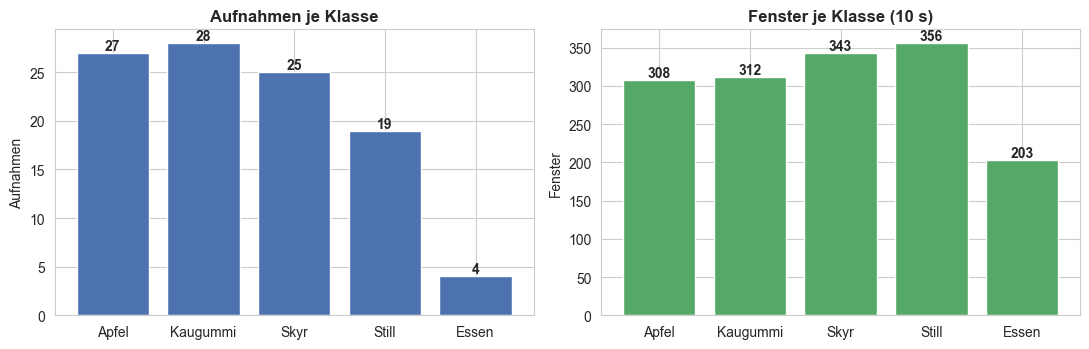

In [4]:
sess_per_class = {cls: sum(1 for c, _, _, _ in session_dfs if c == cls) for cls in CLASSES_RAW}
win_per_class  = {cls: int((y_raw == cls).sum()) for cls in CLASSES_RAW}

print('Klasse      Aufnahmen   Fenster')
for cls in CLASSES_RAW:
    print(f'  {cls:9s} {sess_per_class[cls]:9d} {win_per_class[cls]:9d}')
print(f'  {"GESAMT":9s} {sum(sess_per_class.values()):9d} {sum(win_per_class.values()):9d}')
print()
print('Grob:  Still =', int((y_coarse == "Still").sum()),
      ' Essen =', int((y_coarse == "Essen").sum()))
print('Stufe-2-Fenster (nur Speisen):', int(np.isin(y_raw, FOODS).sum()))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(CLASSES_RAW, [sess_per_class[c] for c in CLASSES_RAW], color='#4C72B0')
axes[0].set_title('Aufnahmen je Klasse', fontweight='bold'); axes[0].set_ylabel('Aufnahmen')
for i, cls in enumerate(CLASSES_RAW):
    axes[0].text(i, sess_per_class[cls], str(sess_per_class[cls]), ha='center', va='bottom', fontweight='bold')
axes[1].bar(CLASSES_RAW, [win_per_class[c] for c in CLASSES_RAW], color='#55A868')
axes[1].set_title('Fenster je Klasse (10 s)', fontweight='bold'); axes[1].set_ylabel('Fenster')
for i, cls in enumerate(CLASSES_RAW):
    axes[1].text(i, win_per_class[cls], str(win_per_class[cls]), ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.savefig(IMG_DIR / 'final_daten.png', dpi=150, bbox_inches='tight'); plt.show()

## 3. Ausgabe 1 — Stufe 1 (LOSO)

RandomForest auf den 14 `FEATURES_S1`, ME-bereinigte Fenster, plus die
`CONF_S1_MIN`-Regel: sagt das Modell `Essen` mit Konfidenz < 0.75, wird auf `Still`
zurueckgestuft. Fenster ohne gueltige ME-Variante sind fest `Still`.

Stufe 1 LOSO Accuracy           : 0.9468
Stufe 1 LOSO balanced Accuracy  : 0.9448
Recall Still                    : 0.9410
Recall Essen                    : 0.9485

Konfusionsmatrix (Zeilen=wahr, Spalten=vorhergesagt), Reihenfolge [Still, Essen]:
[[ 335   21]
 [  60 1106]]

              precision    recall  f1-score   support

       Essen     0.9814    0.9485    0.9647      1166
       Still     0.8481    0.9410    0.8921       356

    accuracy                         0.9468      1522
   macro avg     0.9147    0.9448    0.9284      1522
weighted avg     0.9502    0.9468    0.9477      1522



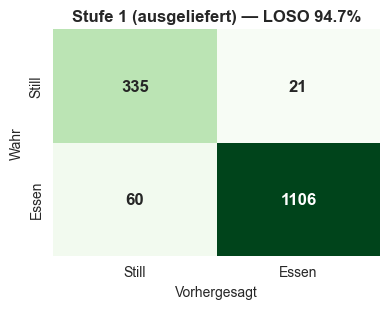

In [5]:
def make_rf():
    return RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RS)


logo = LeaveOneGroupOut()
Xs1 = X_me[FEATURES_S1]

y_true_1, y_pred_1 = [], []
for tr, te in logo.split(Xs1, y_coarse, groups):
    if len(np.unique(y_coarse[tr])) < 2:
        continue
    m1 = make_rf()
    m1.fit(Xs1.iloc[tr], y_coarse[tr])
    proba = m1.predict_proba(Xs1.iloc[te])
    cls_order = m1.classes_
    for j, idx in enumerate(te):
        p = proba[j]
        pred = cls_order[np.argmax(p)]
        conf = float(np.max(p))
        if pred == 'Essen' and conf < CONF_S1_MIN:
            pred = 'Still'
        if not me_ok[idx]:
            pred = 'Still'
        y_true_1.append(y_coarse[idx])
        y_pred_1.append(pred)

y_true_1 = np.array(y_true_1); y_pred_1 = np.array(y_pred_1)

acc_s1  = accuracy_score(y_true_1, y_pred_1)
bacc_s1 = balanced_accuracy_score(y_true_1, y_pred_1)
cm_s1   = confusion_matrix(y_true_1, y_pred_1, labels=['Still', 'Essen'])
rec_still = recall_score(y_true_1, y_pred_1, labels=['Still'], average='macro', zero_division=0)
rec_essen = recall_score(y_true_1, y_pred_1, labels=['Essen'], average='macro', zero_division=0)

print(f'Stufe 1 LOSO Accuracy           : {acc_s1:.4f}')
print(f'Stufe 1 LOSO balanced Accuracy  : {bacc_s1:.4f}')
print(f'Recall Still                    : {rec_still:.4f}')
print(f'Recall Essen                    : {rec_essen:.4f}')
print()
print('Konfusionsmatrix (Zeilen=wahr, Spalten=vorhergesagt), Reihenfolge [Still, Essen]:')
print(cm_s1)
print()
print(classification_report(y_true_1, y_pred_1, digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(4, 3.2))
sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Still', 'Essen'], yticklabels=['Still', 'Essen'],
            annot_kws={'size': 12, 'weight': 'bold'}, ax=ax)
ax.set_title(f'Stufe 1 (ausgeliefert) — LOSO {acc_s1:.1%}', fontweight='bold')
ax.set_xlabel('Vorhergesagt'); ax.set_ylabel('Wahr')
plt.tight_layout(); plt.savefig(IMG_DIR / 'final_stufe1.png', dpi=150, bbox_inches='tight'); plt.show()

## 4. Ausgabe 2 — Stufe 2 (LOSO pro Fenster)

Movement Exclusion AUS, also die rohen Fenster. Die Merkmalsauswahl laeuft **in jeder
Falte neu** und sieht ausschliesslich die Trainingssessions dieser Falte.

In [6]:
def make_svm2(proba=False):
    return Pipeline([('sc', StandardScaler()),
                     ('svm', SVC(kernel='rbf', C=10, class_weight='balanced',
                                 probability=proba, random_state=RS))])


def select_features_train_only(X_tr, y_tr, grp_tr):
    """group-aware permutation importance >= 0 — exakt die App-Regel,
    aber nur auf den uebergebenen Trainingsdaten."""
    imp = np.zeros(X_tr.shape[1])
    n_done = 0
    if len(np.unique(grp_tr)) >= 3:
        gss = GroupShuffleSplit(n_splits=5, test_size=0.3, random_state=RS)
        for tr, te in gss.split(X_tr.values, y_tr, grp_tr):
            if len(np.unique(y_tr[tr])) < 2:
                continue
            p = make_svm2()
            p.fit(X_tr.iloc[tr], y_tr[tr])
            r = permutation_importance(p, X_tr.iloc[te], y_tr[te],
                                       n_repeats=8, random_state=RS, scoring='accuracy')
            imp += r.importances_mean
            n_done += 1
    if n_done:
        imp /= n_done
    pi = pd.Series(imp, index=X_tr.columns)
    feats = [c for c in X_tr.columns if pi[c] >= 0]
    if len(feats) < 5:
        feats = list(X_tr.columns)
    return feats


food_mask = np.isin(y_raw, FOODS)
X_food    = X_raw[food_mask].reset_index(drop=True)
y_food    = y_raw[food_mask]
grp_food  = groups[food_mask]

print(f'Stufe-2-Datensatz: {len(X_food)} Fenster | {len(np.unique(grp_food))} Sessions')

y_true_2, y_pred_2, sess_2 = [], [], []
n_feats_per_fold = []

for k, (tr, te) in enumerate(logo.split(X_food, y_food, grp_food), 1):
    if len(np.unique(y_food[tr])) < 2:
        continue
    feats = select_features_train_only(X_food.iloc[tr].reset_index(drop=True),
                                       y_food[tr], grp_food[tr])
    n_feats_per_fold.append(len(feats))
    m2 = make_svm2()
    m2.fit(X_food.iloc[tr][feats], y_food[tr])
    pred = m2.predict(X_food.iloc[te][feats])
    y_true_2.extend(y_food[te]); y_pred_2.extend(pred); sess_2.extend(grp_food[te])
    if k % 10 == 0:
        print(f'  ... Falte {k}: {len(feats)} Merkmale gewaehlt')

y_true_2 = np.array(y_true_2); y_pred_2 = np.array(y_pred_2); sess_2 = np.array(sess_2)
n_feats_per_fold = np.array(n_feats_per_fold)

acc_s2 = accuracy_score(y_true_2, y_pred_2)
cm_s2  = confusion_matrix(y_true_2, y_pred_2, labels=FOODS)

print()
print(f'Merkmale je Falte: min={n_feats_per_fold.min()}  max={n_feats_per_fold.max()}  '
      f'median={np.median(n_feats_per_fold):.1f}  (von {X_food.shape[1]})')
print(f'Anzahl Falten    : {len(n_feats_per_fold)}')
print()
print(f'Stufe 2 LOSO Accuracy pro Fenster: {acc_s2:.4f}')
print()
print(classification_report(y_true_2, y_pred_2, labels=FOODS, digits=4, zero_division=0))
print(f'Konfusionsmatrix (Zeilen=wahr, Spalten=vorhergesagt), Reihenfolge {FOODS}:')
print(cm_s2)

Stufe-2-Datensatz: 963 Fenster | 80 Sessions


  ... Falte 10: 43 Merkmale gewaehlt


  ... Falte 20: 44 Merkmale gewaehlt


  ... Falte 30: 34 Merkmale gewaehlt


  ... Falte 40: 37 Merkmale gewaehlt


  ... Falte 50: 46 Merkmale gewaehlt


  ... Falte 60: 42 Merkmale gewaehlt


  ... Falte 70: 44 Merkmale gewaehlt


  ... Falte 80: 44 Merkmale gewaehlt

Merkmale je Falte: min=14  max=48  median=42.0  (von 52)
Anzahl Falten    : 80

Stufe 2 LOSO Accuracy pro Fenster: 0.8868

              precision    recall  f1-score   support

       Apfel     0.8260    0.9091    0.8655       308
    Kaugummi     0.8925    0.7981    0.8426       312
        Skyr     0.9420    0.9475    0.9448       343

    accuracy                         0.8868       963
   macro avg     0.8868    0.8849    0.8843       963
weighted avg     0.8889    0.8868    0.8863       963

Konfusionsmatrix (Zeilen=wahr, Spalten=vorhergesagt), Reihenfolge ['Apfel', 'Kaugummi', 'Skyr']:
[[280  24   4]
 [ 47 249  16]
 [ 12   6 325]]


### Ausgabe 3 — Stufe 2 pro Mahlzeit (Mehrheitsvotum je Aufnahme)

Stufe 2 pro Mahlzeit: 0.9500   (76/80 korrekt)

Konfusionsmatrix pro Mahlzeit, Reihenfolge ['Apfel', 'Kaugummi', 'Skyr']:
[[27  0  0]
 [ 2 25  1]
 [ 1  0 24]]

              precision    recall  f1-score   support

       Apfel     0.9000    1.0000    0.9474        27
    Kaugummi     1.0000    0.8929    0.9434        28
        Skyr     0.9600    0.9600    0.9600        25

    accuracy                         0.9500        80
   macro avg     0.9533    0.9510    0.9503        80
weighted avg     0.9537    0.9500    0.9499        80



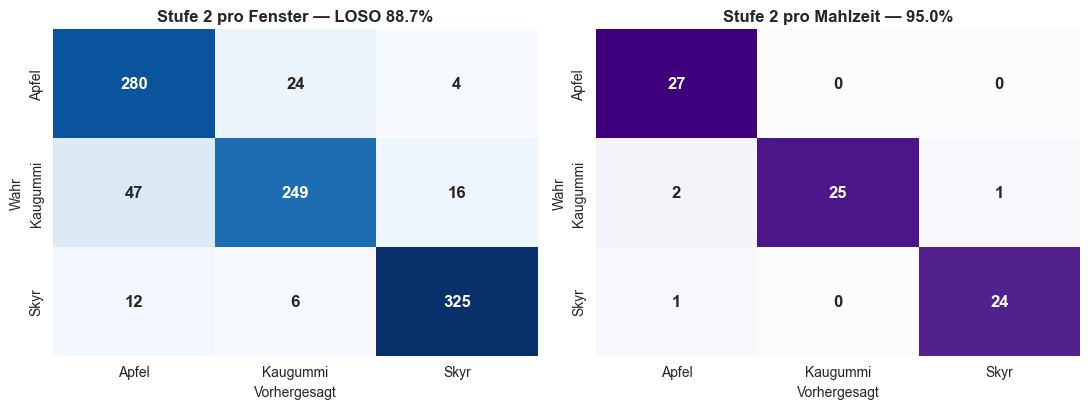

In [7]:
def majority_vote(pred_list, order):
    vals, counts = np.unique(pred_list, return_counts=True)
    best = counts.max()
    tied = [v for v, ct in zip(vals, counts) if ct == best]
    for o in order:                      # deterministischer Tie-Break
        if o in tied:
            return o
    return tied[0]


meal_true, meal_pred = [], []
for s in np.unique(sess_2):
    m = sess_2 == s
    meal_true.append(y_true_2[m][0])
    meal_pred.append(majority_vote(y_pred_2[m], FOODS))

meal_true = np.array(meal_true); meal_pred = np.array(meal_pred)
acc_meal = accuracy_score(meal_true, meal_pred)
cm_meal  = confusion_matrix(meal_true, meal_pred, labels=FOODS)
n_ok     = int((meal_true == meal_pred).sum())

print(f'Stufe 2 pro Mahlzeit: {acc_meal:.4f}   ({n_ok}/{len(meal_true)} korrekt)')
print()
print(f'Konfusionsmatrix pro Mahlzeit, Reihenfolge {FOODS}:')
print(cm_meal)
print()
print(classification_report(meal_true, meal_pred, labels=FOODS, digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=FOODS, yticklabels=FOODS,
            annot_kws={'size': 12, 'weight': 'bold'}, ax=axes[0])
axes[0].set_title(f'Stufe 2 pro Fenster — LOSO {acc_s2:.1%}', fontweight='bold')
axes[0].set_xlabel('Vorhergesagt'); axes[0].set_ylabel('Wahr')
sns.heatmap(cm_meal, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=FOODS, yticklabels=FOODS,
            annot_kws={'size': 12, 'weight': 'bold'}, ax=axes[1])
axes[1].set_title(f'Stufe 2 pro Mahlzeit — {acc_meal:.1%}', fontweight='bold')
axes[1].set_xlabel('Vorhergesagt'); axes[1].set_ylabel('Wahr')
plt.tight_layout(); plt.savefig(IMG_DIR / 'final_stufe2.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Ausgabe 4 — End-to-End (Stufe 1 -> Stufe 2 verkettet)

Beide Stufen faltweise trainiert, dann verkettet: Stufe 1 entscheidet auf dem ME-Fenster,
und nur wenn sie `Essen` sagt, laeuft Stufe 2 auf dem rohen Fenster. Bewertet wird gegen
das feine Label, wobei `Still` eine eigene Vorhersageklasse ist.

Pro Mahlzeit werden nur die Speise-Aufnahmen bewertet: Mehrheitsvotum ueber die Fenster,
die Stufe 1 als `Essen` durchgelassen hat. Laesst Stufe 1 in einer Aufnahme **kein**
Fenster durch, gilt die Mahlzeit als `Still` und damit als Fehler.

In [8]:
labels_e2e = FOODS + ['Still']

y_true_e, y_pred_e, sess_e = [], [], []

for tr, te in logo.split(X_raw, y_raw, groups):
    if len(np.unique(y_coarse[tr])) < 2:
        continue
    # Stufe 1 auf allen Trainingsfenstern
    m1 = make_rf()
    m1.fit(X_me.iloc[tr][FEATURES_S1], y_coarse[tr])
    cls_order = m1.classes_

    # Stufe 2 nur auf den Speise-Fenstern des Trainings, Auswahl train-only
    fm_tr = np.isin(y_raw[tr], FOODS)
    idx_tr_food = tr[fm_tr]
    if len(np.unique(y_raw[idx_tr_food])) < 2:
        continue
    Xf = X_raw.iloc[idx_tr_food].reset_index(drop=True)
    yf = y_raw[idx_tr_food]
    gf = groups[idx_tr_food]
    feats = select_features_train_only(Xf, yf, gf)
    m2 = make_svm2()
    m2.fit(Xf[feats], yf)

    proba1 = m1.predict_proba(X_me.iloc[te][FEATURES_S1])
    for j, idx in enumerate(te):
        p = proba1[j]
        pred1 = cls_order[np.argmax(p)]
        conf1 = float(np.max(p))
        if pred1 == 'Essen' and conf1 < CONF_S1_MIN:
            pred1 = 'Still'
        if not me_ok[idx]:
            pred1 = 'Still'
        if pred1 == 'Still':
            final = 'Still'
        else:
            final = m2.predict(X_raw.iloc[[idx]][feats])[0]
        y_true_e.append(y_raw[idx]); y_pred_e.append(final); sess_e.append(groups[idx])

y_true_e = np.array(y_true_e); y_pred_e = np.array(y_pred_e); sess_e = np.array(sess_e)

# Pro Fenster: alle Fenster, feines Label; 'Essen'-Aufnahmen haben kein feines Ziel ->
# separat ausgewiesen, damit die Hauptzahl vergleichbar zu NB13 bleibt.
eval_mask = np.isin(y_true_e, FOODS + ['Still'])
acc_e2e_win = accuracy_score(y_true_e[eval_mask], y_pred_e[eval_mask])
cm_e2e = confusion_matrix(y_true_e[eval_mask], y_pred_e[eval_mask], labels=labels_e2e)

print(f'End-to-End pro Fenster: {acc_e2e_win:.4f}   (n={int(eval_mask.sum())})')
print(f'  ausgeschlossen (generische Klasse "Essen"): {int((~eval_mask).sum())} Fenster')
print()
print(f'Konfusionsmatrix, Reihenfolge {labels_e2e}:')
print(cm_e2e)
print()
print(classification_report(y_true_e[eval_mask], y_pred_e[eval_mask],
                            labels=labels_e2e, digits=4, zero_division=0))

# Pro Mahlzeit — nur Speise-Aufnahmen
meal_true_e, meal_pred_e = [], []
for s in np.unique(sess_e):
    m = sess_e == s
    truth = y_true_e[m][0]
    if truth not in FOODS:
        continue
    votes = y_pred_e[m]
    food_votes = votes[np.isin(votes, FOODS)]
    meal_true_e.append(truth)
    meal_pred_e.append(majority_vote(food_votes, FOODS) if len(food_votes) else 'Still')

meal_true_e = np.array(meal_true_e); meal_pred_e = np.array(meal_pred_e)
acc_e2e_meal = accuracy_score(meal_true_e, meal_pred_e)
n_ok_e = int((meal_true_e == meal_pred_e).sum())
cm_e2e_meal = confusion_matrix(meal_true_e, meal_pred_e, labels=labels_e2e)

print()
print(f'End-to-End pro Mahlzeit: {acc_e2e_meal:.4f}   ({n_ok_e}/{len(meal_true_e)} korrekt)')
print(f'Konfusionsmatrix pro Mahlzeit, Reihenfolge {labels_e2e}:')
print(cm_e2e_meal)

End-to-End pro Fenster: 0.8749   (n=1319)
  ausgeschlossen (generische Klasse "Essen"): 203 Fenster

Konfusionsmatrix, Reihenfolge ['Apfel', 'Kaugummi', 'Skyr', 'Still']:
[[278  23   3   4]
 [ 47 249  16   0]
 [ 10   4 292  37]
 [  4   4  13 335]]

              precision    recall  f1-score   support

       Apfel     0.8201    0.9026    0.8594       308
    Kaugummi     0.8893    0.7981    0.8412       312
        Skyr     0.9012    0.8513    0.8756       343
       Still     0.8910    0.9410    0.9153       356

    accuracy                         0.8749      1319
   macro avg     0.8754    0.8732    0.8729      1319
weighted avg     0.8767    0.8749    0.8744      1319


End-to-End pro Mahlzeit: 0.9500   (76/80 korrekt)
Konfusionsmatrix pro Mahlzeit, Reihenfolge ['Apfel', 'Kaugummi', 'Skyr', 'Still']:
[[27  0  0  0]
 [ 2 25  1  0]
 [ 1  0 24  0]
 [ 0  0  0  0]]


## 6. Ausgabe 5 — Within-session-Vergleichswert (80/20) und Bewertungsgrafik

Der 80/20-Split mischt Fenster derselben Aufnahme ueber Train und Test — das ist die
optimistische Zahl, die die Bewertungsgrafik der LOSO-Zahl gegenueberstellt. Stufe 2,
Merkmalsauswahl auf dem Trainingsanteil.

Within-session (80/20, Stufe 2): 0.9378   (45 Merkmale)
Cross-session  (LOSO,  Stufe 2): 0.8868
Pro Mahlzeit   (LOSO,  Stufe 2): 0.9500


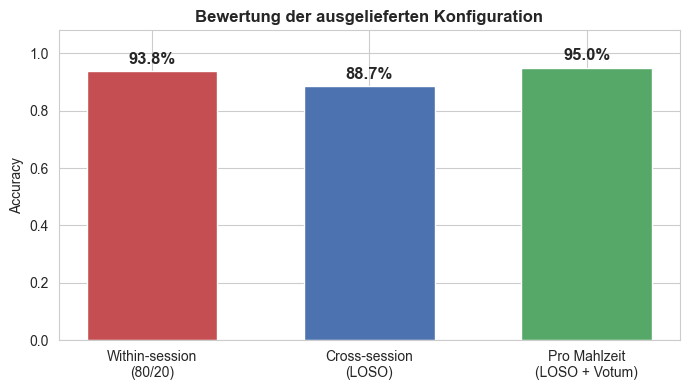

In [9]:
X_tr, X_te, y_tr, y_te, g_tr, g_te = train_test_split(
    X_food, y_food, grp_food, test_size=0.2, random_state=RS, stratify=y_food)

feats_ws = select_features_train_only(X_tr.reset_index(drop=True), y_tr, g_tr)
m_ws = make_svm2()
m_ws.fit(X_tr[feats_ws], y_tr)
acc_within = accuracy_score(y_te, m_ws.predict(X_te[feats_ws]))

print(f'Within-session (80/20, Stufe 2): {acc_within:.4f}   ({len(feats_ws)} Merkmale)')
print(f'Cross-session  (LOSO,  Stufe 2): {acc_s2:.4f}')
print(f'Pro Mahlzeit   (LOSO,  Stufe 2): {acc_meal:.4f}')

vals   = [acc_within, acc_s2, acc_meal]
names  = ['Within-session\n(80/20)', 'Cross-session\n(LOSO)', 'Pro Mahlzeit\n(LOSO + Votum)']
colors = ['#C44E52', '#4C72B0', '#55A868']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, vals, color=colors, width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f'{v:.1%}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.08); ax.set_ylabel('Accuracy')
ax.set_title('Bewertung der ausgelieferten Konfiguration', fontweight='bold')
plt.tight_layout(); plt.savefig(IMG_DIR / 'final_bewertung.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. Zusammenfassung — alle Berichtszahlen an einer Stelle

In [10]:
print('=' * 62)
print('AUSGELIEFERTE KONFIGURATION — ALLE ZAHLEN')
print('=' * 62)
print(f'Datensatz            : {sum(sess_per_class.values())} Aufnahmen, '
      f'{sum(win_per_class.values())} Fenster, {X_raw.shape[1]} Merkmale')
print(f'  je Klasse (Aufn.)  : ' + '  '.join(f'{c}={sess_per_class[c]}' for c in CLASSES_RAW))
print(f'  je Klasse (Fenster): ' + '  '.join(f'{c}={win_per_class[c]}' for c in CLASSES_RAW))
print('-' * 62)
print(f'Stufe 1 LOSO Accuracy          : {acc_s1:.4f}')
print(f'Stufe 1 LOSO balanced Accuracy : {bacc_s1:.4f}')
print(f'Stufe 1 Recall Still           : {rec_still:.4f}')
print(f'Stufe 1 Recall Essen           : {rec_essen:.4f}')
print('-' * 62)
print(f'Stufe 2 LOSO pro Fenster       : {acc_s2:.4f}')
print(f'Stufe 2 pro Mahlzeit           : {acc_meal:.4f}  ({n_ok}/{len(meal_true)})')
print(f'  Merkmale je Falte            : min={n_feats_per_fold.min()} '
      f'max={n_feats_per_fold.max()} median={np.median(n_feats_per_fold):.1f}')
print('-' * 62)
print(f'End-to-End pro Fenster         : {acc_e2e_win:.4f}')
print(f'End-to-End pro Mahlzeit        : {acc_e2e_meal:.4f}  ({n_ok_e}/{len(meal_true_e)})')
print('-' * 62)
print(f'Within-session (80/20)         : {acc_within:.4f}')
print('=' * 62)

AUSGELIEFERTE KONFIGURATION — ALLE ZAHLEN
Datensatz            : 103 Aufnahmen, 1522 Fenster, 52 Merkmale
  je Klasse (Aufn.)  : Apfel=27  Kaugummi=28  Skyr=25  Still=19  Essen=4
  je Klasse (Fenster): Apfel=308  Kaugummi=312  Skyr=343  Still=356  Essen=203
--------------------------------------------------------------
Stufe 1 LOSO Accuracy          : 0.9468
Stufe 1 LOSO balanced Accuracy : 0.9448
Stufe 1 Recall Still           : 0.9410
Stufe 1 Recall Essen           : 0.9485
--------------------------------------------------------------
Stufe 2 LOSO pro Fenster       : 0.8868
Stufe 2 pro Mahlzeit           : 0.9500  (76/80)
  Merkmale je Falte            : min=14 max=48 median=42.0
--------------------------------------------------------------
End-to-End pro Fenster         : 0.8749
End-to-End pro Mahlzeit        : 0.9500  (76/80)
--------------------------------------------------------------
Within-session (80/20)         : 0.9378
